# 🧠 Notebook 3: Neural Network — EfficientNetB0
**Project:** Sports Image Classification  
**โมเดล:** EfficientNetB0 (Pretrained ImageNet) + Fine-tuning

---
### ⚠️ ต้องรัน Notebook 1 ให้เสร็จก่อน
Notebook นี้ใช้รูปจาก `datasets/processed/` ที่เตรียมไว้แล้ว

## ✅ Step 0: ติดตั้ง Libraries

In [1]:
# รันครั้งแรกครั้งเดียว
# !pip install tensorflow matplotlib seaborn scikit-learn

In [2]:
!c:\Users\std48.NAPAT\AppData\Local\Programs\Python\Python311\python.exe -m pip install numpy pandas matplotlib seaborn opencv-python scikit-learn
!c:\Users\std48.NAPAT\AppData\Local\Programs\Python\Python311\python.exe -m pip install scikit-image
!c:\Users\std48.NAPAT\AppData\Local\Programs\Python\Python311\python.exe -m pip install xgboost
!c:\Users\std48.NAPAT\AppData\Local\Programs\Python\Python311\python.exe -m pip install tensorflow


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ------------------------------------- 350.8/350.8 MB 15.2 MB/s eta 0:00:00
     ---------------------------------------- 135.8/135.8 kB ? eta 0:00:00
     ---------------------------------------- 57.5/57.5 kB 3.0 MB/s eta 0:00:00
     --------------------------------------- 26.4/26.4 MB 59.5 MB/s eta 0:00:00
     ---------------------------------------- 71.9/71.9 kB ? eta 0:00:00
     ------------------------------------- 437.9/437.9 kB 28.5 MB/s eta 0:00:00
     ---------------------------------------- 64.7/64.7 kB ? eta 0:00:00
     ---------------------------------------- 60.3/60.3 kB ? eta 0:00:00
     ---------------------------------------- 4.8/4.8 MB 61.4 MB/s eta 0:00:00
     ---------------------------------------- 1.5/1.5 MB 100.2 MB/s eta 0:00:00
     ---------------------------------------- 2.9/2.9 MB 62.3 MB/s eta 0:00:00
     ---------------------------------------- 210.7/210.7 kB ? eta 0:00:00
     ------------------------------------- 310.5/310.5 kB 18.8 MB/s eta 0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## ✅ Step 1: Import & ตั้งค่า Path

In [3]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

print('TensorFlow version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU') or 'ไม่พบ GPU (ใช้ CPU)')

# ======================================================
# ⚠️ แก้ path ให้ตรงกับเครื่องของคุณ
# ======================================================
PROCESSED_PATH = Path(r'../datasets/processed')
MODELS_PATH    = Path(r'../models')
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# ใช้ dataset เดียวกับ ML (dataset2 = 15 class)
DATASET_NAME = 'dataset2'
DATASET_PATH = PROCESSED_PATH / DATASET_NAME
LABEL_MAP_PATH = PROCESSED_PATH / f'{DATASET_NAME}_label_map.json'

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

print(f'Dataset: {DATASET_PATH}')

TensorFlow version: 2.21.0
GPU: ไม่พบ GPU (ใช้ CPU)
Dataset: ..\datasets\processed\dataset2


## ✅ Step 2: โหลด Label Map

In [4]:
with open(LABEL_MAP_PATH) as f:
    label_map = json.load(f)

NUM_CLASSES  = len(label_map)
CLASS_NAMES  = sorted(label_map.keys())

print(f'จำนวน class: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')

จำนวน class: 15
Classes: ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball', 'cricket_ball', 'football', 'golf_ball', 'hockey_ball', 'hockey_puck', 'rugby_ball', 'shuttlecock', 'table_tennis_ball', 'tennis_ball', 'volleyball']


## ✅ Step 3: เตรียม Data Generator
ใช้ `ImageDataGenerator` โหลดรูปและทำ Data Augmentation อัตโนมัติ

In [5]:
# Train: ทำ augmentation เพื่อเพิ่มความหลากหลาย
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# Valid/Test: แค่ normalize ไม่ต้อง augment
val_datagen = ImageDataGenerator(rescale=1./255)

# หา folder valid หรือ test
val_folder = 'valid' if (DATASET_PATH / 'valid').exists() else 'test'

train_gen = train_datagen.flow_from_directory(
    DATASET_PATH / 'train',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    DATASET_PATH / val_folder,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f'Train: {train_gen.samples} รูป')
print(f'Val  : {val_gen.samples} รูป')
print(f'Classes: {list(train_gen.class_indices.keys())[:5]} ...')

Found 7328 images belonging to 15 classes.
Found 1841 images belonging to 15 classes.
Train: 7328 รูป
Val  : 1841 รูป
Classes: ['american_football', 'baseball', 'basketball', 'billiard_ball', 'bowling_ball'] ...


## ✅ Step 4: สร้างโมเดล EfficientNetB0

**แนวคิด Transfer Learning:**
- โหลด EfficientNetB0 ที่ train กับ ImageNet มาแล้ว (รู้จัก feature ทั่วไปแล้ว)
- Freeze layer เดิมทั้งหมด → ต่อ layer ของเราด้านบน
- Phase 1: Train เฉพาะ layer ใหม่
- Phase 2: Unfreeze แล้ว Fine-tune ทั้งโมเดล

In [6]:
def build_model(num_classes):
    # โหลด EfficientNetB0 โดยไม่เอา top layer (include_top=False)
    base_model = EfficientNetB0(
        weights='imagenet',
        include_top=False,
        input_shape=(*IMG_SIZE, 3)
    )
    base_model.trainable = False  # Freeze ก่อน

    # ต่อ layer ของเราเข้าไป
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

model, base_model = build_model(NUM_CLASSES)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         3,855 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,386,482 (16.73 MB)

 Trainable params: 334,351 (1.28 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## ✅ Step 5: Phase 1 — Train เฉพาะ Top Layers (10 epochs)

In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_list = [
    callbacks.EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    callbacks.ModelCheckpoint(
        str(MODELS_PATH / 'nn_best_phase1.keras'),
        save_best_only=True, verbose=1
    )
]

print('=== Phase 1: Training top layers ===')
history1 = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=cb_list
)

=== Phase 1: Training top layers ===
Epoch 1/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.0785 - loss: 3.2190
Epoch 1: val_loss improved from None to 2.70443, saving model to ..\models\nn_best_phase1.keras

Epoch 1: finished saving model to ..\models\nn_best_phase1.keras
229/229 ━━━━━━━━━━━━━━━━━━━━ 99s 409ms/step - accuracy: 0.0794 - loss: 3.1152 - val_accuracy: 0.1027 - val_loss: 2.7044 - learning_rate: 0.0010
Epoch 2/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 348ms/step - accuracy: 0.0830 - loss: 2.8717
Epoch 2: val_loss improved from 2.70443 to 2.70389, saving model to ..\models\nn_best_phase1.keras

Epoch 2: finished saving model to ..\models\nn_best_phase1.keras
229/229 ━━━━━━━━━━━━━━━━━━━━ 94s 409ms/step - accuracy: 0.0838 - loss: 2.8261 - val_accuracy: 0.0853 - val_loss: 2.7039 - learning_rate: 0.0010
Epoch 3/10
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.0796 - loss: 2.7368
Epoch 3: val_loss improved from 2.70389 to 2.70104, saving model to ..\models\nn_bes

## ✅ Step 6: Phase 2 — Fine-tune ทั้งโมเดล (20 epochs)

In [8]:
# Unfreeze base model แล้ว train ทั้งหมดด้วย learning rate ต่ำมาก
base_model.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # ลด lr มากเพื่อไม่ให้ destroy pretrained weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cb_list2 = [
    callbacks.EarlyStopping(patience=7, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    callbacks.ModelCheckpoint(
        str(MODELS_PATH / 'nn_model.keras'),
        save_best_only=True, verbose=1
    )
]

print('=== Phase 2: Fine-tuning full model ===')
history2 = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen,
    callbacks=cb_list2
)

=== Phase 2: Fine-tuning full model ===
Epoch 1/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0868 - loss: 2.7565
Epoch 1: val_loss improved from None to 2.71996, saving model to ..\models\nn_model.keras

Epoch 1: finished saving model to ..\models\nn_model.keras
229/229 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.0996 - loss: 2.7223 - val_accuracy: 0.0760 - val_loss: 2.7200 - learning_rate: 1.0000e-05
Epoch 2/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1420 - loss: 2.6039
Epoch 2: val_loss improved from 2.71996 to 2.55689, saving model to ..\models\nn_model.keras

Epoch 2: finished saving model to ..\models\nn_model.keras
229/229 ━━━━━━━━━━━━━━━━━━━━ 342s 1s/step - accuracy: 0.1460 - loss: 2.5771 - val_accuracy: 0.1559 - val_loss: 2.5569 - learning_rate: 1.0000e-05
Epoch 3/20
229/229 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1850 - loss: 2.4776
Epoch 3: val_loss improved from 2.55689 to 2.34711, saving model to ..\models\nn_model.keras

Epoch 3: finishe

## ✅ Step 7: Plot Training History

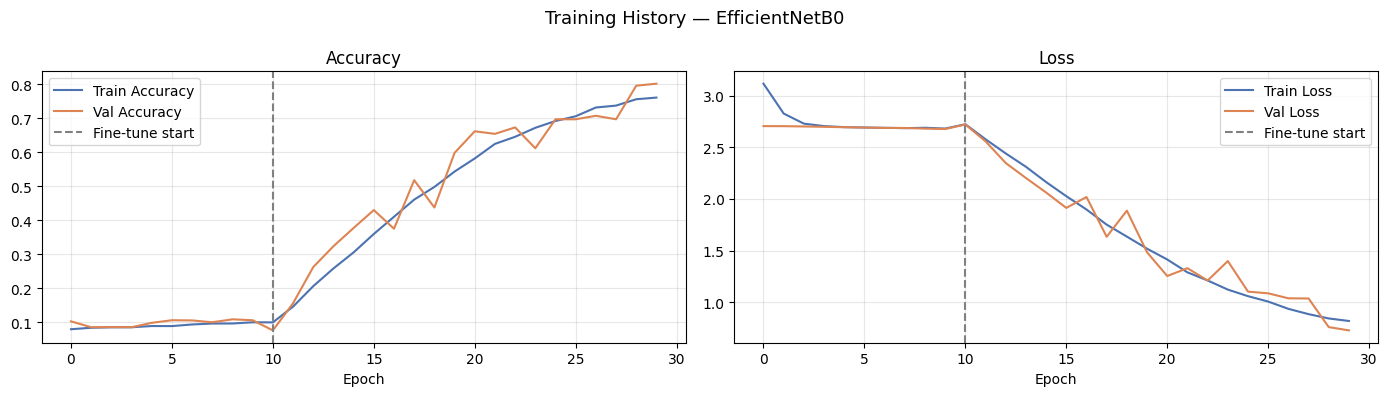

In [9]:
def plot_history(h1, h2):
    # รวม history ทั้ง 2 phase
    acc     = h1.history['accuracy']     + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss    = h1.history['loss']         + h2.history['loss']
    val_loss= h1.history['val_loss']     + h2.history['val_loss']
    phase_split = len(h1.history['accuracy'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for ax, train_v, val_v, title in zip(
        axes,
        [acc, loss],
        [val_acc, val_loss],
        ['Accuracy', 'Loss']
    ):
        ax.plot(train_v, label=f'Train {title}', color='#4C72B0')
        ax.plot(val_v,   label=f'Val {title}',   color='#DD8452')
        ax.axvline(x=phase_split, color='gray', linestyle='--', label='Fine-tune start')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(alpha=0.3)

    plt.suptitle('Training History — EfficientNetB0', fontsize=13)
    plt.tight_layout()
    plt.savefig(PROCESSED_PATH / 'nn_training_history.png', dpi=120)
    plt.show()

plot_history(history1, history2)

## ✅ Step 8: Evaluate บน Val/Test Set

In [10]:
# โหลดโมเดลที่ดีที่สุด
best_model = tf.keras.models.load_model(MODELS_PATH / 'nn_model.keras')

loss, acc = best_model.evaluate(val_gen, verbose=0)
print(f'Neural Network Accuracy: {acc*100:.2f}%')
print(f'Loss: {loss:.4f}')

Neural Network Accuracy: 80.23%
Loss: 0.7273


In [11]:
# Classification Report + Confusion Matrix
val_gen.reset()
y_pred_proba = best_model.predict(val_gen, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_gen.classes

# class names ตาม index ของ generator
gen_classes = [k for k, v in sorted(val_gen.class_indices.items(), key=lambda x: x[1])]

print('Classification Report — EfficientNetB0')
print('='*60)
print(classification_report(y_true, y_pred, target_names=gen_classes))

Classification Report — EfficientNetB0
                   precision    recall  f1-score   support

american_football       0.85      0.81      0.83        96
         baseball       0.97      0.77      0.86       100
       basketball       0.84      0.81      0.83        86
    billiard_ball       0.85      0.86      0.86       162
     bowling_ball       0.76      0.77      0.76       111
     cricket_ball       0.88      0.84      0.86       146
         football       0.72      0.93      0.81       151
        golf_ball       0.78      0.77      0.77       138
      hockey_ball       0.68      0.61      0.64       133
      hockey_puck       0.80      0.77      0.78        98
       rugby_ball       0.81      0.77      0.79       124
      shuttlecock       0.81      0.90      0.85       108
table_tennis_ball       0.77      0.84      0.80       156
      tennis_ball       0.83      0.80      0.82       123
       volleyball       0.80      0.74      0.77       109

         accura

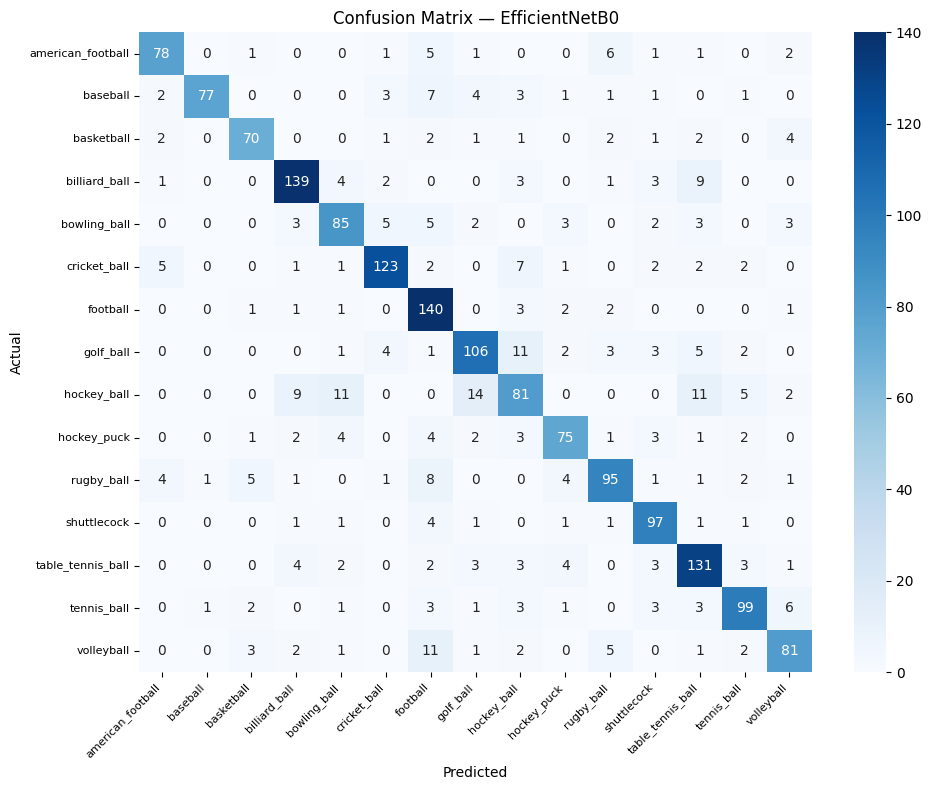

In [12]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=gen_classes,
            yticklabels=gen_classes)
plt.title('Confusion Matrix — EfficientNetB0')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(PROCESSED_PATH / 'nn_confusion_matrix.png', dpi=120)
plt.show()

## ✅ Step 9: ทดสอบ Predict รูปใหม่ (ใช้ใน Streamlit)

In [13]:
import cv2

def predict_nn(img_path, model, class_indices):
    """
    รับ path รูป → return class ที่ทำนาย + confidence
    ฟังก์ชันนี้จะถูกใช้ใน Streamlit app
    """
    idx_to_class = {v: k for k, v in class_indices.items()}
    img = cv2.imread(str(img_path))
    if img is None:
        return None, 0.0
    img = cv2.resize(img, IMG_SIZE)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)  # เพิ่ม batch dimension
    proba      = model.predict(img, verbose=0)[0]
    pred_idx   = np.argmax(proba)
    confidence = proba[pred_idx]
    return idx_to_class[pred_idx], float(confidence)

# ทดสอบ
sample_classes = list(val_gen.class_indices.keys())[:3]
for cls_name in sample_classes:
    cls_path = DATASET_PATH / val_folder / cls_name
    imgs = list(cls_path.glob('*.jpg'))[:1]
    if imgs:
        pred, conf = predict_nn(imgs[0], best_model, val_gen.class_indices)
        correct = '✅' if pred == cls_name else '❌'
        print(f'{correct} Actual: {cls_name:<20} Predicted: {pred:<20} Confidence: {conf*100:.1f}%')

✅ Actual: american_football    Predicted: american_football    Confidence: 98.7%
❌ Actual: baseball             Predicted: football             Confidence: 18.9%
✅ Actual: basketball           Predicted: basketball           Confidence: 79.1%


## 📋 Step 10: สรุปผล

In [14]:
print('='*55)
print('สรุป Neural Network Model')
print('='*55)
print(f"""
Architecture   : EfficientNetB0 (Pretrained ImageNet)
Dataset        : {DATASET_NAME} ({NUM_CLASSES} classes)
Input size     : {IMG_SIZE[0]}x{IMG_SIZE[1]}x3

Training Strategy:
  Phase 1 — Freeze base, train top layers (lr=1e-3)
  Phase 2 — Unfreeze all, fine-tune (lr=1e-5)

Data Augmentation:
  - Rotation ±20°
  - Width/Height shift 10%
  - Horizontal flip
  - Zoom 10%

Val Accuracy   : {acc*100:.2f}%

ไฟล์ที่บันทึก:
  models/nn_model.keras
""")

สรุป Neural Network Model

Architecture   : EfficientNetB0 (Pretrained ImageNet)
Dataset        : dataset2 (15 classes)
Input size     : 224x224x3

Training Strategy:
  Phase 1 — Freeze base, train top layers (lr=1e-3)
  Phase 2 — Unfreeze all, fine-tune (lr=1e-5)

Data Augmentation:
  - Rotation ±20°
  - Width/Height shift 10%
  - Horizontal flip
  - Zoom 10%

Val Accuracy   : 80.23%

ไฟล์ที่บันทึก:
  models/nn_model.keras

